# Chatbot with Long Term Store Memory , TrustCall and Collection Schema

## Review:
- previously we explored short term and Long term memory, Memory store and trustcall
### short-term Memory : 
- Memory limited to a session or thread.
- Memory is lost when the session ends
### long-term Memory :
#### Multi session DB
- Simple multi session memory stored in a DB (SQLite, PostGress)
### multi session/thread store
-  Memory is stored in a store as
      - single user profile JSON key and value pair 
      - memory is updated either by regenerating while updating or as a JSON patch to existing memory
- Uses put, get and search method to manipulate the store
- important objects are namespace, key and value
- uses TrustCall to avoid LLm regenerating memory with every update to reduce cost and latency
- trust call only generates JSON objects for new and updated information while preserving the exiting memory.

## Goal:
-  Save memory as collection/List of profiles or documents
    - Allows for smaller, narrowly scoped memories w/ easy addition of new information
- use TrustCall to generate JSON patch of new information to update the existing memory

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"


In [2]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [3]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Wednesday, May 22, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHyP+tMG1Mlx0032sz7HDyiOMT9Lqzcz3bqJSBwFecM/FEgfetsjOmBE4LROrW'}}]

## Defining Collection Schema

- Instead of updating the profiel object every time, collection save the new information as new JSON doc .
-EX:
1. What a “collection schema” is
Instead of:
```
# One big profile
{
  "user_name": "Diya",
  "age": 31,
  "interests": ["gardening", "hiking"],
  ...
}
```
You store many small entries, each one a single memory:
```
# Many small docs
{
  "content": "User likes gardening",
  "memory_type": "preference",
  "source": "chat",
  "importance": 0.7,
}
{
  "content": "User lives in San Antonio",
  "memory_type": "fact",
  "source": "chat",
  "importance": 0.9,
}
```
- Each of these is one row in your “memories collection”.
- Each memory will be stored as a separate entry with a single content field for the main information we want to remember
- Use collection schema as a struvtured output

Pros:
- Avoids updating the whole profile
- model may overwrite or change information
- tracking and observability isnt possible
- can not store ambiguous , open ended facts
- avoids cost and latency



In [56]:
# Example:

# define the collection schema as pydantic BaseModel
from pydantic import BaseModel ,  Field
from typing import List
from langchain_core.messages import HumanMessage , AIMessage , SystemMessage

# define memory
class Memory(BaseModel):
    content: str = Field(description="Content of the memory .For Example: User said he likes to travel to Europe")

#Define main memory collection schema
class Memory_collection(BaseModel):
    memories: List[Memory] = Field(description="list of memories about the user")

# set up chat messages
msg = HumanMessage(content="Hi, Im Diya. I love reading books. I would love to visit the Library tomorrow")

# get response from the LLM
response = llm.with_structured_output(Memory_collection).invoke([msg])
response.memories

[Memory(content="User's name is Diya."),
 Memory(content='Diya loves reading books.'),
 Memory(content='Diya plans to visit the library tomorrow.')]

## model_dump() - serialize pydantic model instance into a dictionary

In [57]:
for m in response.memories:
    print(m.model_dump())

{'content': "User's name is Diya."}
{'content': 'Diya loves reading books.'}
{'content': 'Diya plans to visit the library tomorrow.'}


### Store Memory
- store memory as a collection of dictionary objects with different keys

In [58]:
# define user_id and  namespace 
user_id = "1"
namespace = ('memories' , user_id)
# get key
import uuid


# set store
from langgraph.store.memory import InMemoryStore
store_memory = InMemoryStore()

# store memory objects as individual values with different keys
for m in response.memories:
    value = m.model_dump()
    print(value)
    key  = str(uuid.uuid4())
    print(key)
    store_memory.put(namespace, key , value)

    

{'content': "User's name is Diya."}
60d50ca5-a280-4b15-9332-d1c07660a0d1
{'content': 'Diya loves reading books.'}
52bc4fc3-2756-4039-9b54-9d942b353901
{'content': 'Diya plans to visit the library tomorrow.'}
1a1b455d-a0de-4ef4-8c87-5a0f676a0325


## check for memory
- Notice that memory is a collection of objects
- each collection is a individual key and value pair
- 


In [59]:
memory = store_memory.search(namespace)
for m in memory:
    print(m.dict())
    print("\n")

{'namespace': ['memories', '1'], 'key': '60d50ca5-a280-4b15-9332-d1c07660a0d1', 'value': {'content': "User's name is Diya."}, 'created_at': '2026-06-07T20:52:15.886623+00:00', 'updated_at': '2026-06-07T20:52:15.886623+00:00', 'score': None}


{'namespace': ['memories', '1'], 'key': '52bc4fc3-2756-4039-9b54-9d942b353901', 'value': {'content': 'Diya loves reading books.'}, 'created_at': '2026-06-07T20:52:15.888630+00:00', 'updated_at': '2026-06-07T20:52:15.888630+00:00', 'score': None}


{'namespace': ['memories', '1'], 'key': '1a1b455d-a0de-4ef4-8c87-5a0f676a0325', 'value': {'content': 'Diya plans to visit the library tomorrow.'}, 'created_at': '2026-06-07T20:52:15.888630+00:00', 'updated_at': '2026-06-07T20:52:15.888630+00:00', 'score': None}




## Upading collection schema
- update the collection with new memory as well existing collection
- use TrustaCall to avoid overwriting the collection everytime (cost , latency , token usage).
- TrustCall generates JSON patch and creats new collection and updates existing collection

### TrustCall memory extractor
- create a trustcall extractor
- 1. Extract memory as a single object
- 2. Extract memory as a collection

### 1. Single profile |memory

In [85]:
# create a truscall extractor
from trustcall import create_extractor

trustcall_extractor = create_extractor(
    llm,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True
)


# set up chat messages
from langchain_core.messages import HumanMessage, AIMessage , SystemMessage



conversation = [HumanMessage(content="Hi, THis is Diya. I lvoe gardening. I want to find a nursary to buy plants"), 
                AIMessage(content="Nice to meet you Diya. That's great!. what kind of plants do you like?"),
                HumanMessage(content="I love flower plants. I like colors"),
               ]

system_msg = SystemMessage(content="you are a memory extractor for collection and storing.  extract memories from the chat messages given below")

#extract memory
result_memory = trustcall_extractor.invoke({'messages' : [system_msg] + conversation })


In [86]:
result_memory

{'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'Memory', 'arguments': '{"content": "User\'s name is Diya. She loves gardening, specifically flower plants, and enjoys colorful plants. She is looking for a nursery to buy plants."}'}, '__gemini_function_call_thought_signatures__': {'b27847d2-84c7-498b-b96f-ccb7a890822c': 'EjQKMgEMOdbHz4iMeWMdGnl4Bh66pCHMjLk2KjKEU5BQbP7fSejLO0Ug7I9NNRXzmM9BXyEO'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea4ac-8e5f-74e3-a03e-26b2d9475985-0', tool_calls=[{'name': 'Memory', 'args': {'content': "User's name is Diya. She loves gardening, specifically flower plants, and enjoys colorful plants. She is looking for a nursery to buy plants."}, 'id': 'b27847d2-84c7-498b-b96f-ccb7a890822c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 131, 'output_tokens': 44, 'total_tokens': 175, 'input_

In [95]:
result_memory['responses'][-1].model_dump()

{'content': "User's name is Diya. She loves gardening, specifically flower plants, and enjoys colorful plants. She is looking for a nursery to buy plants."}

In [96]:
id = result['messages'][-1].tool_calls[-1]['id']
id

'2a52976b-c670-4d91-92d8-9134c7ebe38f'

### 2. Collection of TrustCall memory objects 

In [77]:
trustcall_extractor = create_extractor(
    llm,
    tools=[Memory_collection],
    tool_choice="Memory_collection",
    enable_inserts=True
)


# set up chat messages
from langchain_core.messages import HumanMessage, AIMessage , SystemMessage



conversation = [HumanMessage(content="Hi, THis is Diya. I love gardening. I want to find a nursary to buy plants"), 
                AIMessage(content="Nice to meet you Diya. That's great!. what kind of plants do you like?"),
                HumanMessage(content="I love flower plants. I like colors"),
               ]

system_msg = SystemMessage(content="you are a memory extractor for collection and storing.  extract memories from the chat messages given below")

#extract memory
result = trustcall_extractor.invoke({'messages' : [system_msg] + conversation })

Key '$defs' is not supported in schema, ignoring


## ⭐ Why TrustCall cannot extract lists
TrustCall internally:
- Validates a single schema
- Generates a JSON Patch for a single object
- Applies updates to a single object

#### It cannot:
- Patch a list
- Insert into a list
- Validate nested models
- Handle $defs from Pydantic

#### So this will never work:
```
class Memory_collection(BaseModel):
    memories: List[memory]
```
TrustCall will always ignore $defs and fail.

## ⭐ The correct LangGraph pattern (recommended by LangChain team)
✔ Extract one memory
✔ Store it as one document
✔ Build a collection over time

### Example:
```
result = trustcall_extractor.invoke({...})

if result.content.strip():
    store.put(namespace, None, result.model_dump())
```
Passing `None` lets the store auto‑generate a unique key.

## This is exactly how:
- MemoryGPT
- LangGraph course examples
- ReAct agents
- Long‑term memory agents
- are built.

In [82]:
result

{'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'Memory_collection', 'arguments': '{"memories": [{"content": "User\'s name is Diya."}, {"content": "Diya loves gardening."}, {"content": "Diya loves flower plants and likes colors."}]}'}, '__gemini_function_call_thought_signatures__': {'2a52976b-c670-4d91-92d8-9134c7ebe38f': 'EjQKMgEMOdbHoO3d/y126V9G8GeYKM/swijJPX0tNqfig1ZemUGij0bRJfXp8mx8ZGOi3u1t'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea3e2-a21c-72c2-97cd-1c13fc8f8751-0', tool_calls=[{'name': 'Memory_collection', 'args': {'memories': [{'content': "User's name is Diya."}, {'content': 'Diya loves gardening.'}, {'content': 'Diya loves flower plants and likes colors.'}]}, 'id': '2a52976b-c670-4d91-92d8-9134c7ebe38f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 176, 'output_tokens': 51, 'total_tokens': 227, '

In [81]:
storeMemories = result['responses']
storeMemories

[Memory_collection(memories=[Memory(content="User's name is Diya."), Memory(content='Diya loves gardening.'), Memory(content='Diya loves flower plants and likes colors.')])]

# get existing memory

In [101]:
existing_memory = [ (str(i) , 'Memory' , msg.model_dump()) for i, msg in enumerate(result_memory['responses'])] if result['responses'] else None
existing_memory

[('0',
  'Memory',
  {'content': "User's name is Diya. She loves gardening, specifically flower plants, and enjoys colorful plants. She is looking for a nursery to buy plants."})]

### Update memory

In [108]:
# set conversation
new_conversation = [AIMessage(content="Cool! What your favorite color? "),
                    HumanMessage(content="I like blue but, my favorite flower plant is Rose and Hibiscus.  I love pink flowers"),
                   ]

# sys_intr for memory extraction
sys_instr = SystemMessage(content="Create new memories  based on the following conversation given below and Update existing memories. perform both action")

updated_memory = trustcall_extractor.invoke({'messages': [sys_instr] + new_conversation , 
                                             'existing' : existing_memory })

                 

In [109]:
updated_memory

{'messages': [AIMessage(content=[], additional_kwargs={'updated_docs': {'6807df62-3c6a-4a4a-b53c-a93b9642d37e': '0'}}, response_metadata={}, id='8c6380c7-47ce-47c4-96be-a09b267abc28', tool_calls=[{'name': 'Memory', 'args': {'content': 'Diya likes blue, and her favorite flower plants are Roses and Hibiscus. She specifically loves pink flowers.'}, 'id': '3d058d59-1a0f-4729-842e-51d4d7cb5767', 'type': 'tool_call'}, {'name': 'Memory', 'args': {'content': "User's name is Diya. She loves gardening, specifically flower plants like Roses and Hibiscus. She enjoys colorful plants, especially pink ones, and her favorite color is blue. She is looking for a nursery to buy plants."}, 'id': '6807df62-3c6a-4a4a-b53c-a93b9642d37e', 'type': 'tool_call'}], invalid_tool_calls=[])],
 'responses': [Memory(content='Diya likes blue, and her favorite flower plants are Roses and Hibiscus. She specifically loves pink flowers.'),
  Memory(content="User's name is Diya. She loves gardening, specifically flower plan

In [110]:
updated_memory['messages'][0].pretty_print()

================================== Ai Message ==================================

[]
Tool Calls:
  Memory (3d058d59-1a0f-4729-842e-51d4d7cb5767)
 Call ID: 3d058d59-1a0f-4729-842e-51d4d7cb5767
  Args:
    content: Diya likes blue, and her favorite flower plants are Roses and Hibiscus. She specifically loves pink flowers.
  Memory (6807df62-3c6a-4a4a-b53c-a93b9642d37e)
 Call ID: 6807df62-3c6a-4a4a-b53c-a93b9642d37e
  Args:
    content: User's name is Diya. She loves gardening, specifically flower plants like Roses and Hibiscus. She enjoys colorful plants, especially pink ones, and her favorite color is blue. She is looking for a nursery to buy plants.


In [112]:
updated_memory['responses']

[Memory(content='Diya likes blue, and her favorite flower plants are Roses and Hibiscus. She specifically loves pink flowers.'),
 Memory(content="User's name is Diya. She loves gardening, specifically flower plants like Roses and Hibiscus. She enjoys colorful plants, especially pink ones, and her favorite color is blue. She is looking for a nursery to buy plants.")]

In [132]:
# update store
updatedStore = InMemoryStore()
nameS = ('Memory' , user_id)
for i, m in enumerate(updated_memory['responses']): 
    updatedStore.put(nameS , i , m.model_dump())
up_memory = updatedStore.search(nameS)
up_memory

[Item(namespace=['Memory', '1'], key='0', value={'content': 'Diya likes blue, and her favorite flower plants are Roses and Hibiscus. She specifically loves pink flowers.'}, created_at='2026-06-08T17:44:54.835112+00:00', updated_at='2026-06-08T17:44:54.835112+00:00', score=None),
 Item(namespace=['Memory', '1'], key='1', value={'content': "User's name is Diya. She loves gardening, specifically flower plants like Roses and Hibiscus. She enjoys colorful plants, especially pink ones, and her favorite color is blue. She is looking for a nursery to buy plants."}, created_at='2026-06-08T17:44:54.835112+00:00', updated_at='2026-06-08T17:44:54.835112+00:00', score=None)]

In [137]:
for m in up_memory:
    print("key:", m.key , " memory,", " Value:", m.value)
    print("\n")
existing_upmemory_content = (",").join([m.value['content'] for m in up_memory])
existing_upmemory_content

key: 0  memory,  Value: {'content': 'Diya likes blue, and her favorite flower plants are Roses and Hibiscus. She specifically loves pink flowers.'}


key: 1  memory,  Value: {'content': "User's name is Diya. She loves gardening, specifically flower plants like Roses and Hibiscus. She enjoys colorful plants, especially pink ones, and her favorite color is blue. She is looking for a nursery to buy plants."}




"Diya likes blue, and her favorite flower plants are Roses and Hibiscus. She specifically loves pink flowers.,User's name is Diya. She loves gardening, specifically flower plants like Roses and Hibiscus. She enjoys colorful plants, especially pink ones, and her favorite color is blue. She is looking for a nursery to buy plants."

# create a chatbot with collection memory

In [307]:
# Define class model for TrustCall extraction
from pydantic import BaseModel, Field
from langgraph.graph import MessagesState , StateGraph , START , END
from langchain_core.runnables.config import RunnableConfig
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore 
from langchain_core.messages import HumanMessage , SystemMessage
from trustcall import create_extractor

from langchain_core.messages import merge_message_runs


class Store_memory(BaseModel):
    content: str = Field(description=" collected information about the user. Example : User name is 'Raj' . user wants  to plan a trip to Japan")

# create a trustCall extractor
trust_extractor = create_extractor(llm,
                                   tools=[Store_memory],
                                   tool_choice= "Store_memory",
                                   enable_inserts=True,
                                    )

# write a LLM response node
llm_inst = ''' You are a helpful asistant with memory .  Your job is to respond to the user message given to you below. 
            Theroughly review the memory before  personalizing your response . keep these in mind:
            1. Do not hallucinate or invent information.
            2. Do not omit information present in the memory.
            3. Keep your response real and facutal. 
            4. be proffesional 
            5. memory may be empty or None
            Here is your memory : {memory}'''

def chat_model(state:MessagesState , config: RunnableConfig , store:BaseStore):
    ''' LLm response to user message'''
    # get existing memory
    user_id  = config['configurable']['user_id']
    #print(user_id)
    namespace = ('memory', user_id)
    # get existing memory
    existing_memory = store.search(namespace) # list of collections
    #print(existing_memory)
    
    # join the list of memory contents
    existing_memory_content = ((",").join([m.value['content'] for m in existing_memory])if existing_memory else None)

    # set system instruction
    sys_info = [SystemMessage(content=llm_inst.format(memory = existing_memory_content))]

    Get_response = llm.invoke(sys_info + state['messages'])
    #print(Get_response)
    # update state
    return {'messages': [Get_response] }

# update memory
trustcall_sys_inst = """Reflect on following interaction. 

Use the provided tools to retain any necessary memories about the user. Create new memory . Update only if needed or thre is a confict of information.
Do not modify existing memory if there is no conflict.Use parallel tool calling to handle updates and insertions simultaneously:"""

def update_memory(state:MessagesState , config:RunnableConfig , store:BaseStore):
    ''' update existing memory and create new ones'''
     # get existing memory
    user_id  = config['configurable']['user_id']
    namespace = ('memory', user_id)
    tool_name = "Store_memory"
    
    # get existing memory
    existing_memory_items = store.search(namespace) 

    # extract key, value and name as a tuple
    existing_memory =([(m.key , tool_name, m.value) for m in existing_memory_items] if existing_memory_items else None)
    #print(existing_memory)
    
    # set sys instruction
    sys_ins = [SystemMessage(content=trustcall_sys_inst)]

    # Merge the chat history and the instruction
    updated_messages=list(merge_message_runs(messages=sys_ins + state["messages"]))

    # call extractor with key and value for existing memory
    
    trust_result = trust_extractor.invoke({'messages': updated_messages, 
                                        'existing': existing_memory })
    
    # update store
    print("trust_result:" , trust_result)
    for i, m in enumerate(trust_result['responses']):
        #print(trust_result['response_metadata'][i]['id'])
        store.put(namespace , trust_result['response_metadata'][i].get('json_doc_id', str(uuid.uuid4())) , m.model_dump(mode = 'json'),)
    return  state              
    

### Build graph

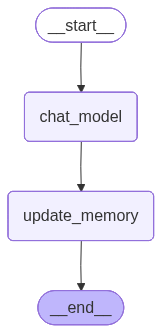

In [308]:
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver
# builder
builder = StateGraph(MessagesState)

# add nodes
builder.add_node('chat_model' , chat_model)
builder.add_node('update_memory' , update_memory)

# add flow
builder.add_edge(START , 'chat_model')
builder.add_edge('chat_model', 'update_memory')
builder.add_edge('update_memory', END)

# set up check pointer an dlong term memory
checkpointer = MemorySaver() # session base

store_memory = InMemoryStore() # across thread memory

# build graph and compile
graph = builder.compile(checkpointer=checkpointer , store=store_memory)

# view
from IPython.display import display , Image

display(Image(graph.get_graph().draw_mermaid_png()))

### Invoke graph


In [309]:
# set configuration
config = {"configurable" : { 'thread_id': "1" , 'user_id': "1" }}

user_msg1 = HumanMessage(content="Hi, I'm Diya. I was thinking about trying new restaurants today. ANy leads?")

# invoke graph
for chunk in graph.stream({'messages' : [user_msg1] }, config , stream_mode="updates"):
    print("-"*40)
    print(chunk)
    chunk = chunk

----------------------------------------
{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': "Hi Diya! It's nice to meet you. Since I don't have any information about your location or your personal food preferences yet, I can't give you specific recommendations just yet.\n\nTo help me provide the best leads for you, could you let me know:\n\n1. **What city or neighborhood are you in?**\n2. **What kind of cuisine are you in the mood for?** (e.g., Italian, Sushi, Mexican, etc.)\n3. **Are you looking for a specific vibe?** (e.g., casual, fine dining, a good spot for a group, or somewhere quiet?)\n\nOnce you share those details, I'd be happy to help you find some great options!", 'extras': {'signature': 'EjQKMgEMOdbHeugh5wKxSk+NDIxO+Xb0D1F1bxjxpYi+Okn7iEXEFlVpYaWU4uYNtQkE/lYf'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea99d-0f8c-7a3

###  Check store and state

In [310]:
user_id = "1"
namespace= ("memory" , user_id)

# search store
store_info = store_memory.search(namespace)
store_info[-1].dict()


{'namespace': ['memory', '1'],
 'key': 'b1b9b409-f9c3-4876-89b9-ed0d0c6fc179',
 'value': {'content': "User's name is Diya. She is interested in trying new restaurants."},
 'created_at': '2026-06-08T23:41:44.892447+00:00',
 'updated_at': '2026-06-08T23:41:44.892447+00:00',
 'score': None}

In [311]:
# check state
state_info = graph.get_state(config)
state_info.values


{'messages': [HumanMessage(content="Hi, I'm Diya. I was thinking about trying new restaurants today. ANy leads?", additional_kwargs={}, response_metadata={}, id='66e2dd44-191c-4cc0-90d7-4208a6aec2c7'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Diya! It's nice to meet you. Since I don't have any information about your location or your personal food preferences yet, I can't give you specific recommendations just yet.\n\nTo help me provide the best leads for you, could you let me know:\n\n1. **What city or neighborhood are you in?**\n2. **What kind of cuisine are you in the mood for?** (e.g., Italian, Sushi, Mexican, etc.)\n3. **Are you looking for a specific vibe?** (e.g., casual, fine dining, a good spot for a group, or somewhere quiet?)\n\nOnce you share those details, I'd be happy to help you find some great options!", 'extras': {'signature': 'EjQKMgEMOdbHeugh5wKxSk+NDIxO+Xb0D1F1bxjxpYi+Okn7iEXEFlVpYaWU4uYNtQkE/lYf'}}], additional_kwargs={}, response_metadata={'finish_reason':

### continue conversation

In [312]:
user_msg2 = HumanMessage(content="I live in Irving, TX.  I would love some Indian vegiterian food. Find an icecream shop nearby as well.")
# invoke graph
# invoke graph
for chunk in graph.stream({'messages' : [user_msg2] }, config , stream_mode="updates"):
    
    print(chunk)
    print("-"*40)
    chunk = chunk

{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': "It is great to hear from you again, Diya! Since you are in Irving, TX, and looking for Indian vegetarian cuisine followed by some ice cream, here are a few highly-rated options for you to consider:\n\n### Indian Vegetarian Restaurants in Irving\n*   **Veggie Garden:** This is a popular spot in Irving known specifically for its vegetarian and vegan Indian dishes. It is well-regarded for its authentic flavors and extensive menu.\n*   **Urban Tadka:** While they serve a variety of dishes, they have excellent vegetarian options. It is a great place if you are looking for a slightly more modern or upscale dining atmosphere.\n*   **Bawarchi Biryani (Irving location):** They are very well-known in the area. While they serve meat, they have a dedicated vegetarian section on their menu that is quite extensive and highly rated by locals.\n\n### Ice Cream Shops Nearby\n*   **Creamistry (Irving/Las Colinas):** If you want a 

### Check store
-  must have 2 collection of memories

In [313]:
user_id = "1"
namespace= ("memory" , user_id)

# search store
store_info = store_memory.search(namespace)
store_info

[Item(namespace=['memory', '1'], key='b1b9b409-f9c3-4876-89b9-ed0d0c6fc179', value={'content': "User's name is Diya. She is interested in trying new restaurants."}, created_at='2026-06-08T23:41:44.892447+00:00', updated_at='2026-06-08T23:41:44.892447+00:00', score=None),
 Item(namespace=['memory', '1'], key='dd103559-8435-4a8f-8104-af3063d8d829', value={'content': 'Diya lives in Irving, TX. She enjoys Indian vegetarian food and likes ice cream.'}, created_at='2026-06-08T23:42:05.379955+00:00', updated_at='2026-06-08T23:42:05.379955+00:00', score=None)]